In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [2]:
df = pd.read_csv("bodyfat.csv")
df

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,1.0736,11.0,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5
248,1.0236,33.6,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1
249,1.0328,29.3,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0
250,1.0399,26.0,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8


In [3]:
df.dtypes

Density    float64
BodyFat    float64
Age          int64
Weight     float64
Height     float64
Neck       float64
Chest      float64
Abdomen    float64
Hip        float64
Thigh      float64
Knee       float64
Ankle      float64
Biceps     float64
Forearm    float64
Wrist      float64
dtype: object

In [4]:
X = df.drop('BodyFat', axis=1)
y = df['BodyFat']

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 201
Validation set size: 25
Test set size: 26


In [7]:
model = Sequential([
    Input(shape=(X_train.shape[1],),name='input'),
    Dense(128, activation='relu',name='d1'),  # Hidden layer with 8 neurons
    Dense(64, activation='relu',name='d2'),  # Hidden layer with 4 neurons
    Dense(32, activation='relu',name='d3'),  # Hidden layer with 4 neurons
    Dense(1)
])

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 d1 (Dense)                  (None, 128)               1920      
                                                                 
 d2 (Dense)                  (None, 64)                8256      
                                                                 
 d3 (Dense)                  (None, 32)                2080      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 12289 (48.00 KB)
Trainable params: 12289 (48.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mean_squared_error', metrics=['mae'])

In [10]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=80,batch_size=32)

Epoch 1/80
7/7 [==============================] - 1s 45ms/step - loss: 314.0023 - mae: 15.3877 - val_loss: 480.2623 - val_mae: 9.6369
Epoch 2/80
7/7 [==============================] - 0s 8ms/step - loss: 105.0070 - mae: 8.0569 - val_loss: 80.1030 - val_mae: 6.8807
Epoch 3/80
7/7 [==============================] - 0s 8ms/step - loss: 48.2478 - mae: 5.7976 - val_loss: 71.7533 - val_mae: 4.8633
Epoch 4/80
7/7 [==============================] - 0s 8ms/step - loss: 28.0655 - mae: 4.2405 - val_loss: 17.3055 - val_mae: 3.2080
Epoch 5/80
7/7 [==============================] - 0s 8ms/step - loss: 12.6363 - mae: 2.8257 - val_loss: 13.4124 - val_mae: 2.7567
Epoch 6/80
7/7 [==============================] - 0s 7ms/step - loss: 9.3167 - mae: 2.3901 - val_loss: 7.7025 - val_mae: 2.3306
Epoch 7/80
7/7 [==============================] - 0s 8ms/step - loss: 6.4722 - mae: 1.9798 - val_loss: 8.9370 - val_mae: 2.3712
Epoch 8/80
7/7 [==============================] - 0s 7ms/step - loss: 5.3381 - mae: 1.805

7/7 [==============================] - 0s 8ms/step - loss: 0.4763 - mae: 0.4944 - val_loss: 0.7399 - val_mae: 0.7276
Epoch 65/80
7/7 [==============================] - 0s 8ms/step - loss: 0.4185 - mae: 0.4452 - val_loss: 1.0951 - val_mae: 0.6627
Epoch 66/80
7/7 [==============================] - 0s 8ms/step - loss: 0.3137 - mae: 0.3401 - val_loss: 1.7767 - val_mae: 0.7488
Epoch 67/80
7/7 [==============================] - 0s 8ms/step - loss: 0.4803 - mae: 0.4799 - val_loss: 2.9419 - val_mae: 0.9232
Epoch 68/80
7/7 [==============================] - 0s 8ms/step - loss: 0.5307 - mae: 0.5032 - val_loss: 2.4899 - val_mae: 0.9542
Epoch 69/80
7/7 [==============================] - 0s 8ms/step - loss: 0.3694 - mae: 0.4381 - val_loss: 1.3159 - val_mae: 0.7493
Epoch 70/80
7/7 [==============================] - 0s 7ms/step - loss: 0.2702 - mae: 0.3392 - val_loss: 1.7705 - val_mae: 0.7320
Epoch 71/80
7/7 [==============================] - 0s 8ms/step - loss: 0.2362 - mae: 0.2925 - val_loss: 1.699

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 [==============================] - 0s 37ms/step - loss: 1.7578 - mae: 0.6169
Test Loss: 1.757842779159546
Test Accuracy: 0.616939127445221


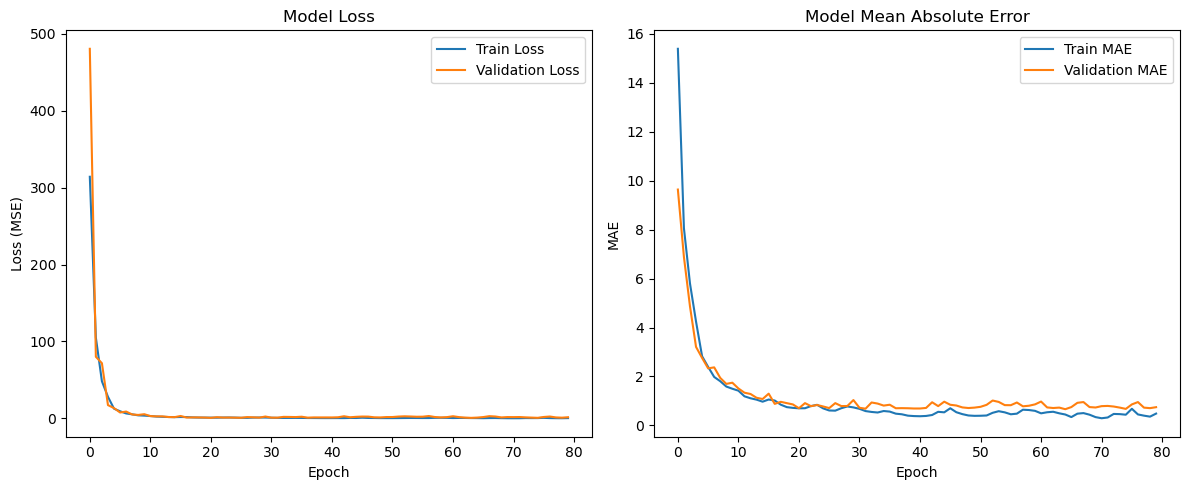

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


### inference:
- in this loss vs epoch graph. The training and validation losses decrease and converge at a similar loss, hence it is an ideal architecture.